# ING Employerer-Branding Diagnosis: ING vs Santander, BNP-Paribas & Deutsche-Bank

**Dataset:** Glassdoor Job Reviews 1 & 2 — David Gauthier ([Kaggle](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews)). Merged and filtered into a single Parquet file (July 2018 - July 2023, firms with 300+ reviews).

**Objective:** Identify ING's strengths (to exploit in employer branding and recruitment) and improvement areas (the ones driving employees out), always compared against its main competitors.

## 0. SetUp

### 0.1. Imports

In [28]:
# Standard library
import re
from pathlib import Path

# Dataframe management
import pandas as pd
import numpy as np

# Graphs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

# NLP
import torch
from transformers import pipeline
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

### 0.2. Project Config

In [29]:
# Data_Path
DATA_PATH = Path("data/data.parquet")

# Selected firms
TARGET = "ING"
PEERS = ["Santander", "BNP-Paribas", "Deutsche-Bank"]
FIRMS = [TARGET] + PEERS

# Reviews CAP per firm ~ 1500
MAX_REVIEWS_PER_FIRM = 1500

# Reproducibility
SEED = 5

# Plot style ~ Color Branding
sns.set_theme(style = "whitegrid")

PALETTE = {
    TARGET: "#FF6200",
    "Santander": "#EC0000",
    "BNP-Paribas": "#00915A",
    "Deutsche-Bank": "#0018A8"
    }

# Auxiliar function for decoloring
def lighten(color, amount = 0.5):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)


### 0.3. Data import

In [30]:
# RELEVANT data import from data/data.parquet
full_df = pd.read_parquet(DATA_PATH, filters=[("firm", "in", FIRMS)])

### 0.4. Balanced Sampling

The whole project (EDA and NLP) works with a balanced sample of `MAX_REVIEWS_PER_FIRM` reviews per firm, so no firm has more weight than the others in the joint topic model and computing time stays reasonable for the transformer models. Sampling happens right after loading, so I don't clean or explore reviews that won't be used.

To keep each firm's own composition, the sample is stratified by year and current/former status (proportional allocation), with a fixed seed so the whole project is reproducible.

In [31]:
# Stratification by Year & Current/Former
strata = pd.to_datetime(full_df["date_review"]).dt.year.astype(str) + "_" + full_df["current"].str.split().str[0]

samples = []

for firm, g in full_df.groupby("firm"):

    # % Reviews to keep
    fraction = min(1, MAX_REVIEWS_PER_FIRM / len(g))

    # Stratified sampling
    out = g.groupby(strata[g.index]).sample(frac=fraction, random_state=SEED)

    # Rounding in each stratum can overshoot the cap, so trim back to MAX_REVIEWS_PER_FIRM.
    if len(out) > MAX_REVIEWS_PER_FIRM:
        out = out.sample(n = MAX_REVIEWS_PER_FIRM, random_state=SEED)

    samples.append(out)

# Sampled DF (working df)
raw_df = pd.concat(samples, ignore_index=True)

print(f"Working sample: {len(raw_df)} reviews")

Working sample: 5998 reviews


**Sampling check**

Composition of the sample vs. the full data. `mean_rating` was not used to stratify, so it is a real test of representativeness.

In [32]:
def composition(df):
    return pd.DataFrame({
        "pct_current": df.groupby("firm")["current"].apply(lambda s: s.str.lower().str.startswith("current").mean() * 100),
        "mean_rating": df.groupby("firm")["overall_rating"].mean(),
    })

sampling_check = (pd.DataFrame({"available": full_df["firm"].value_counts(), "sample": raw_df["firm"].value_counts()})
                  .join(composition(full_df).add_suffix("_full"))
                  .join(composition(raw_df).add_suffix("_sample"))
                  .loc[FIRMS].round(2))

sampling_check

,available,sample,pct_current_full,mean_rating_full,pct_current_sample,mean_rating_sample
firm,,,,,,
ING,1681,1500,67.28,4.00,67.27,4.00
Santander,2638,1499,60.65,3.57,60.71,3.59
BNP-Paribas,4455,1499,64.62,3.66,64.64,3.68
Deutsche-Bank,5474,1500,62.99,3.73,63.00,3.71


## 1. EDA

### 1.1. DataFrame Quality Analysis

**DataFrame dimensions**

In [33]:
print(f"Rows: {raw_df.shape[0]}")
print(f"Cols: {raw_df.shape[1]}")

Rows: 5998
Cols: 7


**Col type (& nulls)**

In [34]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firm            5998 non-null   str    
 1   date_review     5998 non-null   object 
 2   current         5998 non-null   str    
 3   overall_rating  5998 non-null   float64
 4   recommend       5998 non-null   str    
 5   pros            5998 non-null   str    
 6   cons            5998 non-null   str    
dtypes: float64(1), object(1), str(5)
memory usage: 1.3+ MB


**Duplicates Count**

In [35]:
dupl_count = raw_df.duplicated().sum()
print("Duplicates: ", dupl_count)

Duplicates:  0


**Reviews per firm**

In [36]:
print(raw_df["firm"].value_counts())

firm
Deutsche-Bank    1500
ING              1500
BNP-Paribas      1499
Santander        1499
Name: count, dtype: int64


### 1.2. Col Casting & Parsing

**Fixing Current**

`Current` mixes employment status and tenure (e.g. _"Former Employee, more than 3 years"_), so I split it into two variables.

In [37]:
# Current / Former
def get_status(s):
    s = str(s).lower()
    if s.startswith("current"):
        return "Current"
    if s.startswith("former"):
        return "Former"
    return "Unknown"

# Tenure
def get_tenure(s):
    m = re.search(r"(less|more) than (\d+) year", str(s))
    return f"{m.group(1)} than {m.group(2)}y" if m else "n/a"

# Applying
raw_df["status"] = raw_df["current"].map(get_status)
raw_df["tenure"] = raw_df["current"].map(get_tenure)

**Tenure Styling**

In [38]:
# Styling
mapping = {
    'n/a': 'N/A',
    'more than 1y': '+1',
    'less than 1y': '-1',
    'more than 3y': '+3',
    'more than 5y': '+5',
    'more than 8y': '+8',
    'more than 10y': '+10'
}

raw_df['tenure'] = raw_df['tenure'].replace(mapping)

# Ordering
raw_df['tenure'] = pd.Categorical(raw_df['tenure'], categories=['-1', '+1', '+3', '+5', '+8', '+10', 'N/A'], ordered=True)

**Recomemend Fixing**

`Recommend` is translated from its code (v = yes, o = no opinion, x = no).

In [39]:
# Fix
raw_df["recommends"] = raw_df["recommend"].map({"v": "Yes", "o": "Neutral", "x": "No"})

# Removing old recommend
raw_df = raw_df.drop(columns=["recommend"])

**Date casting**

In [40]:
# Casting
raw_df["date_review"] = pd.to_datetime(raw_df["date_review"])

# Extracting year
raw_df["year"] = raw_df["date_review"].dt.year

**Categorical firm**

This way ING will always be the first firm.

In [41]:
raw_df["firm"] = pd.Categorical(raw_df["firm"], categories=FIRMS, ordered=True)

**Text cleaning**

In [42]:
# Normalizing whitespaces
for col in ["pros", "cons"]:
    raw_df[col] = (raw_df[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip())

# Empty reviews
print((raw_df[["pros", "cons"]] == "").sum())

pros    0
cons    0
dtype: int64


### 1.3. Data Understanding

Before comparing firms, I check how each variable is distributed to know what the data looks like and which analyses are viable. The whole EDA uses the balanced sample (`clean_df`).

In [43]:
clean_df = raw_df.copy()

**Date Range**

In [44]:
print("\nDate range:", raw_df["date_review"].min(), "->", raw_df["date_review"].max())


Date range: 2018-07-27 00:00:00 -> 2023-04-23 00:00:00


**Reviews per year and firm**

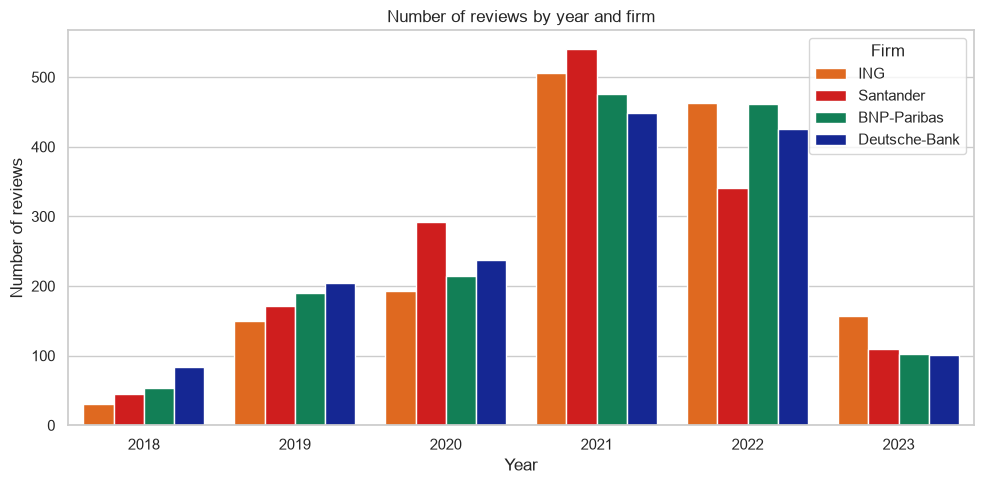

In [45]:
years = sorted(clean_df["year"].unique())

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=clean_df, x="year", hue="firm", order=years, hue_order=FIRMS, palette=PALETTE, ax=ax)

ax.set_title("Number of reviews by year and firm")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reviews")
ax.legend(title="Firm")

plt.tight_layout()
plt.show()

While 2021–2022 are predominant, 2018 & 2023 are incompleted years.

**Current vs Former Reviews per Firm**

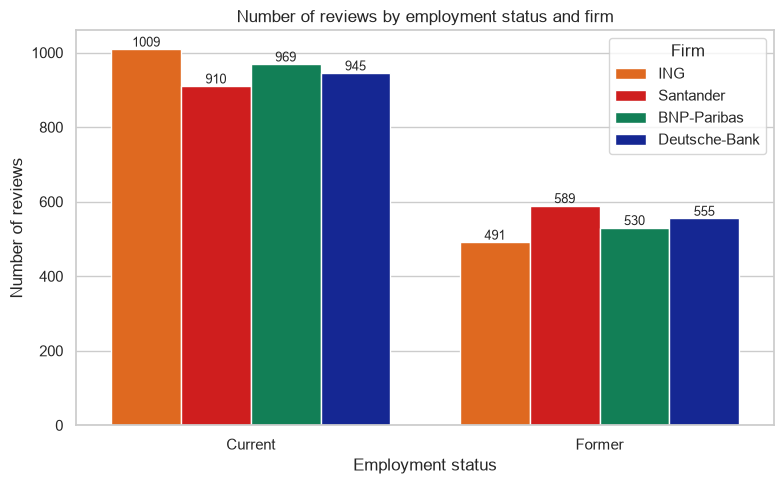

In [46]:
# Number of reviews by employment status and firm
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=clean_df, x="status", hue="firm", order=["Current", "Former"],
              hue_order=FIRMS, palette=PALETTE, ax=ax)

# Count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

ax.set_title("Number of reviews by employment status and firm")
ax.set_xlabel("Employment status")
ax.set_ylabel("Number of reviews")
ax.legend(title="Firm")

plt.tight_layout()
plt.show()

Current employee reviews double those of former employees, resulting in a 66–33 split. Regarding ING, it shows the highest proportion of reviews from current employees and, consequently, the lowest relative proportion of former employees compared to its competitors.

**Rating distribution**

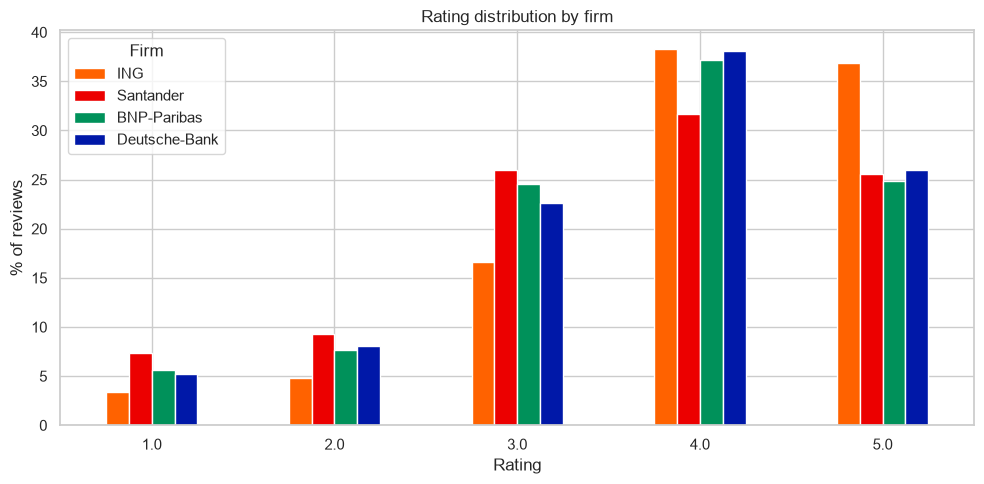

In [47]:
# % of reviews by score, for each firm
rating_dist = pd.crosstab(clean_df["firm"], clean_df["overall_rating"], normalize="index").mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
rating_dist.T.plot(kind="bar", color=[PALETTE[firm] for firm in rating_dist.index], ax=ax)

ax.set_title("Rating distribution by firm")
ax.set_xlabel("Rating")
ax.set_ylabel("% of reviews")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Firm")

plt.tight_layout()
plt.show()

All firms exhibit heavily skewed positive ratings, likely an artifact of platform bias, since companies typically encourage only satisfied employees to leave Glassdoor reviews. Even within this skewed baseline, ING features the most favorable distribution: a heavier concentration of 4- and 5-star ratings.

**Tenure by Firm**

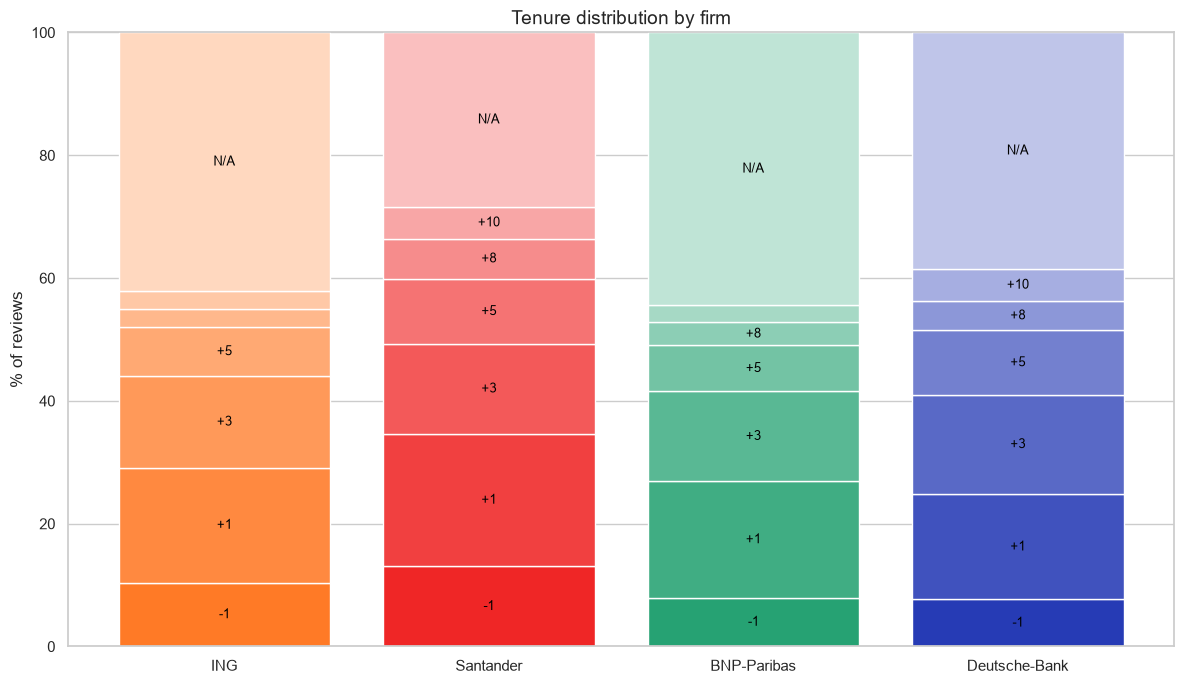

In [48]:
# Tenure distribution by firm
tenure_dist = (
    pd.crosstab(
        clean_df["firm"],
        clean_df["tenure"],
        normalize="index"
    )
    .mul(100)
    .reindex(FIRMS)
    .reindex(columns=['-1', '+1', '+3', '+5', '+8', '+10', 'N/A'])
)

fig, ax = plt.subplots(figsize=(12, 7))

bottom = np.zeros(len(tenure_dist))

for i, tenure_cat in enumerate(tenure_dist.columns):
    values = tenure_dist[tenure_cat].values

    bars = ax.bar(
        tenure_dist.index,
        values,
        bottom=bottom,
        color=[lighten(PALETTE[firm], 0.15 + i * 0.10) for firm in FIRMS],
        edgecolor="white",
        linewidth=1
    )

    # Add tenure labels inside each segment
    for j, (bar, value) in enumerate(zip(bars, values)):
        if value >= 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + value / 2,
                tenure_cat,
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

    bottom += values

ax.set_title("Tenure distribution by firm", fontsize=14)
ax.set_ylabel("% of reviews")
ax.set_ylim(0, 100)

# Remove legend
ax.legend().remove()

plt.tight_layout()
plt.show()

Tenure profiles vary across firms, with ING and BNP-Paribas showing a relatively high proportion of reviews with missing tenure information. Santander and Deutsche Bank provide a more distributed representation across tenure levels.

**Text length**

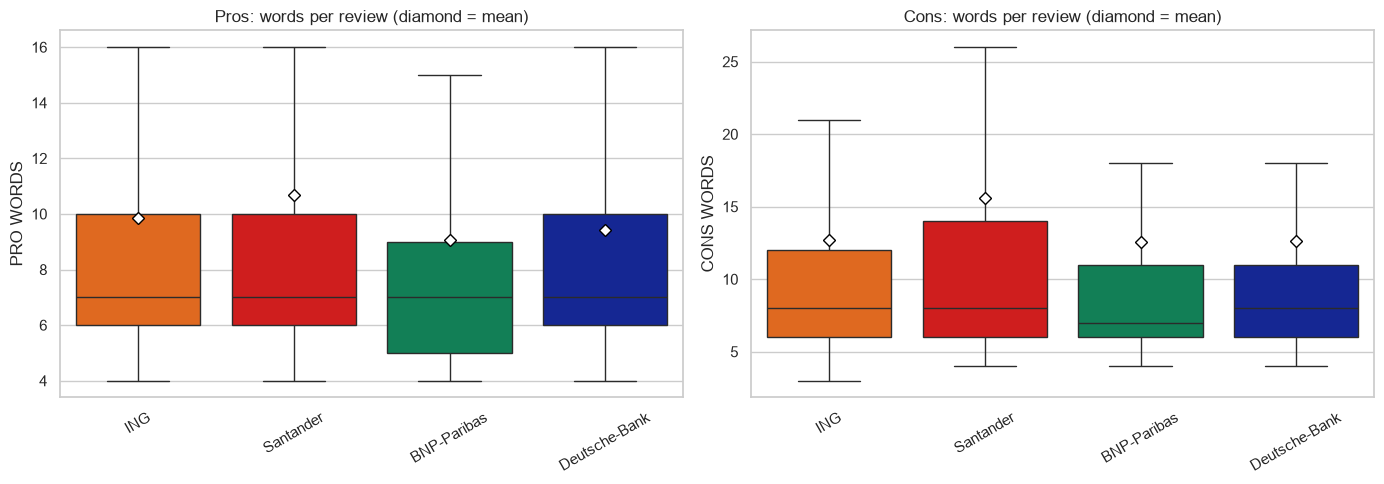

n_words_pros: 0.0% of reviews above 350 words
n_words_cons: 0.05% of reviews above 350 words


In [49]:
clean_df["n_words_pros"] = clean_df["pros"].str.split().str.len()
clean_df["n_words_cons"] = clean_df["cons"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, ylabel in zip(
    axes,
    ["n_words_pros", "n_words_cons"],
    ["Pros", "Cons"],
    ["PRO WORDS", "CONS WORDS"],
):

    sns.boxplot(data=clean_df, x="firm", y=col, hue="firm", order=FIRMS, hue_order=FIRMS,
            palette=PALETTE, legend=False, dodge=False, showfliers=False, showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"}, ax=ax)
    
    ax.set_title(f"{title}: words per review (diamond = mean)")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Transformers truncate at 512 tokens (~350-400 words), so check how many reviews would be cut
for col in ["n_words_pros", "n_words_cons"]:
    print(f"{col}: {round((clean_df[col] > 350).mean() * 100, 2)}% of reviews above 350 words")

Reviews are relatively short and show similar lengths across companies, with the "cons" slightly longer than the "pros." Virtually no reviews exceed the ~350-word threshold used as a reference for transformer input. Therefore, truncation should not result in any significant loss of information for the NLP analysis.

### 1.4. Business focused analysis

**Firm summary**

In [50]:
with_opinion = clean_df[clean_df["recommends"].isin(["Yes", "No"])]

# Mean rating + 95% CI
rating_stats = clean_df.groupby("firm", observed=True)["overall_rating"].agg(["mean", "sem"])
mean_ci = rating_stats.apply(
    lambda r: f"{r['mean']:.2f} [{r['mean'] - 1.96 * r['sem']:.2f}, {r['mean'] + 1.96 * r['sem']:.2f}]",
    axis=1,
)

summary = pd.DataFrame({
    "Reviews": clean_df["firm"].value_counts(),         # All revs
    "RevsWithOp": with_opinion["firm"].value_counts(),  # Only non-neutral revs
    "Mean [CI 95%]": mean_ci,
    "%Recommend": (clean_df["recommends"] == "Yes").groupby(clean_df["firm"], observed=True).mean() * 100,                  # % Recomendación on ALL revs
    "%NoResponse": (clean_df["recommends"] == "Neutral").groupby(clean_df["firm"], observed=True).mean() * 100,             # % NEUTRAL revs
    "%RecommendWithOp": (with_opinion["recommends"] == "Yes").groupby(with_opinion["firm"], observed=True).mean() * 100,    # % Recomendación on NON-NEUTRAL revs
}).loc[FIRMS].rename_axis("Firm").round(2)

summary

,Reviews,RevsWithOp,Mean [CI 95%],%Recommend,%NoResponse,%RecommendWithOp
Firm,,,,,,
ING,1500,855,"4.00 [3.95, 4.06]",46.67,43.00,81.87
Santander,1499,1016,"3.59 [3.53, 3.65]",41.96,32.22,61.91
BNP-Paribas,1499,884,"3.68 [3.62, 3.74]",43.43,41.03,73.64
Deutsche-Bank,1500,954,"3.71 [3.66, 3.77]",44.53,36.40,70.02


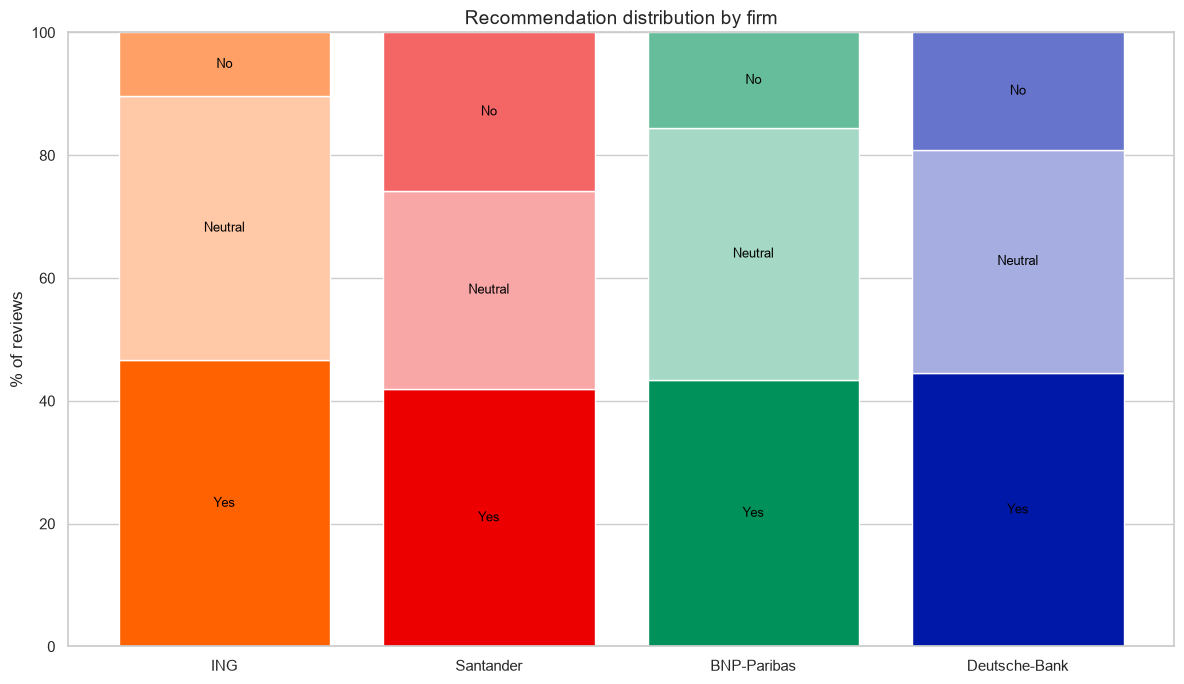

In [51]:
# Recommendation distribution by firm
recommendation_dist = (
    pd.crosstab(
        clean_df["firm"],
        clean_df["recommends"],
        normalize="index"
    )
    .mul(100)
    .reindex(FIRMS)
    .reindex(columns=["Yes", "Neutral", "No"])
)

fig, ax = plt.subplots(figsize=(12, 7))

for i, firm in enumerate(FIRMS):
    values = recommendation_dist.loc[firm]

    colors = [
        PALETTE[firm],                  # Yes -> dark
        lighten(PALETTE[firm], 0.65),   # Neutral -> greyish
        lighten(PALETTE[firm], 0.40)    # No -> light
    ]

    bottom = 0

    for j, recommendation in enumerate(["Yes", "Neutral", "No"]):
        value = values[recommendation]

        ax.bar(
            firm,
            value,
            bottom=bottom,
            color=colors[j],
            edgecolor="white",
            linewidth=1
        )

        # Add recommendation label instead of percentage
        if value >= 5:
            ax.text(
                i,
                bottom + value / 2,
                recommendation,
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

        bottom += value

ax.set_title("Recommendation distribution by firm", fontsize=14)
ax.set_ylabel("% of reviews")
ax.set_ylim(0, 100)

# Remove legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout()
plt.show()

ING boasts the best average rating (4.00) and the highest recommendation rate conditional on expressing an opinion (81.87%), clearly outperforming all three competitors. However, the hefty 43% share of neutral responses makes the overall recommendation percentage far less informative.

**Rating evolution**

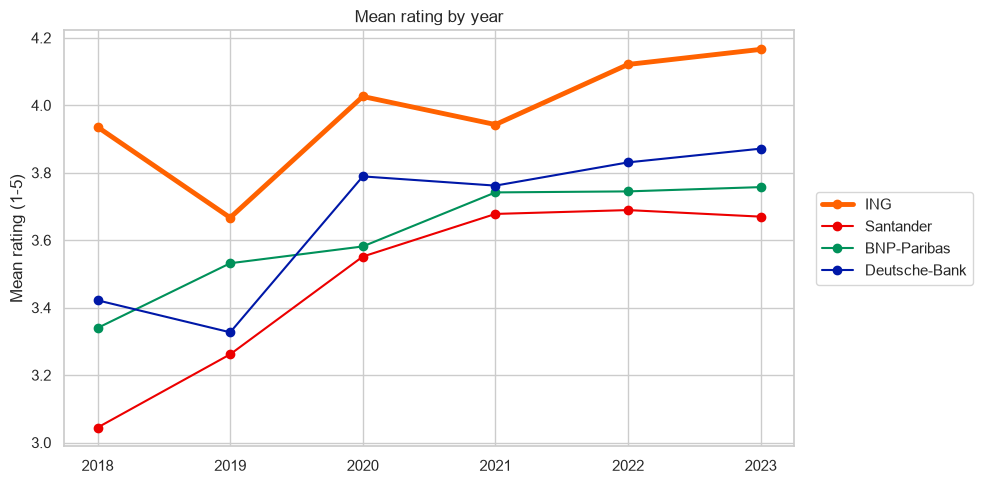

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))

for firm in FIRMS:
    firm_year = clean_df[clean_df["firm"] == firm].groupby("year")["overall_rating"].mean()
    ax.plot(firm_year.index, firm_year.values, marker="o", color=PALETTE[firm],
            lw=3.5 if firm == TARGET else 1.5, label=firm)

ax.set_title("Mean rating by year")
ax.set_ylabel("Mean rating (1-5)")
ax.set_xticks(sorted(clean_df["year"].unique()))
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

ING maintains the highest average rating throughout the entire period, finishing 2023 above 4.00, while its competitors remain below 3.9. ING's advantage is therefore persistent and does not appear to rely on a single year, though it has experienced standard cyclical fluctuations rather than flatlining into a straight line.

**Rating ~ Employment status (current vs. former)**

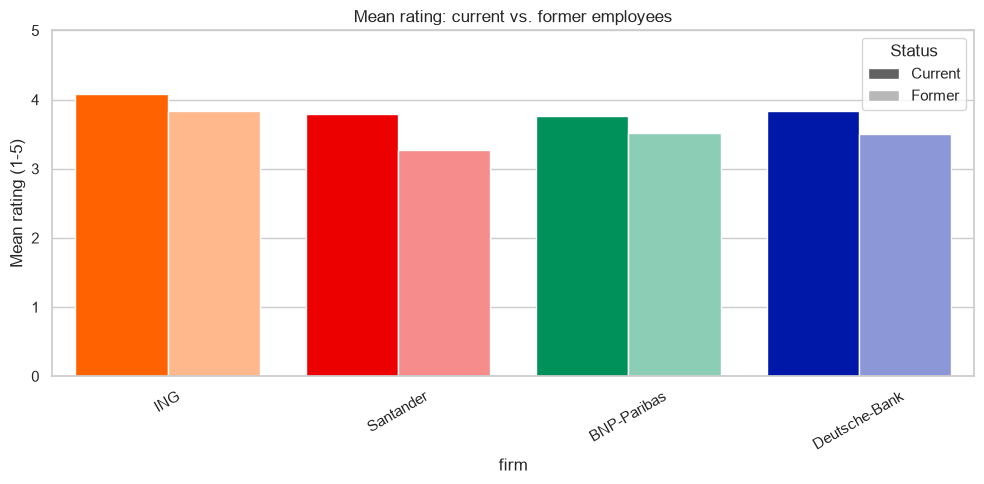

In [53]:
status_df = clean_df[clean_df["status"] != "Unknown"]

gap = status_df.pivot_table(index="firm", columns="status", values="overall_rating", aggfunc="mean", observed=True).loc[FIRMS]
gap["gap (Current - Former)"] = gap["Current"] - gap["Former"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=status_df, x="firm", y="overall_rating", hue="status", order=FIRMS,
            hue_order=["Current", "Former"], errorbar=None, ax=ax)

# One container per hue level (Current, Former), each one with one bar per firm (in FIRMS order)
for container, status in zip(ax.containers, ["Current", "Former"]):
    for bar, firm in zip(container, FIRMS):
        bar.set_facecolor(PALETTE[firm] if status == "Current" else lighten(PALETTE[firm], 0.55))

# Color now encodes the firm, so the legend only explains solid vs. light (neutral gray)
ax.legend(handles=[Patch(facecolor="#616161", label="Current"),
                   Patch(facecolor=lighten("#616161", 0.55), label="Former")],
          title="Status")

ax.set_title("Mean rating: current vs. former employees")
ax.set_ylabel("Mean rating (1-5)")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Current employee ratings outpace those of former employees across all four firms, yet ING leads the pack in both categories (Current at ~4.1, Former at ~3.8). This proves ING's competitive edge isn't just an illusion propped up by people still cashing their paycheck.

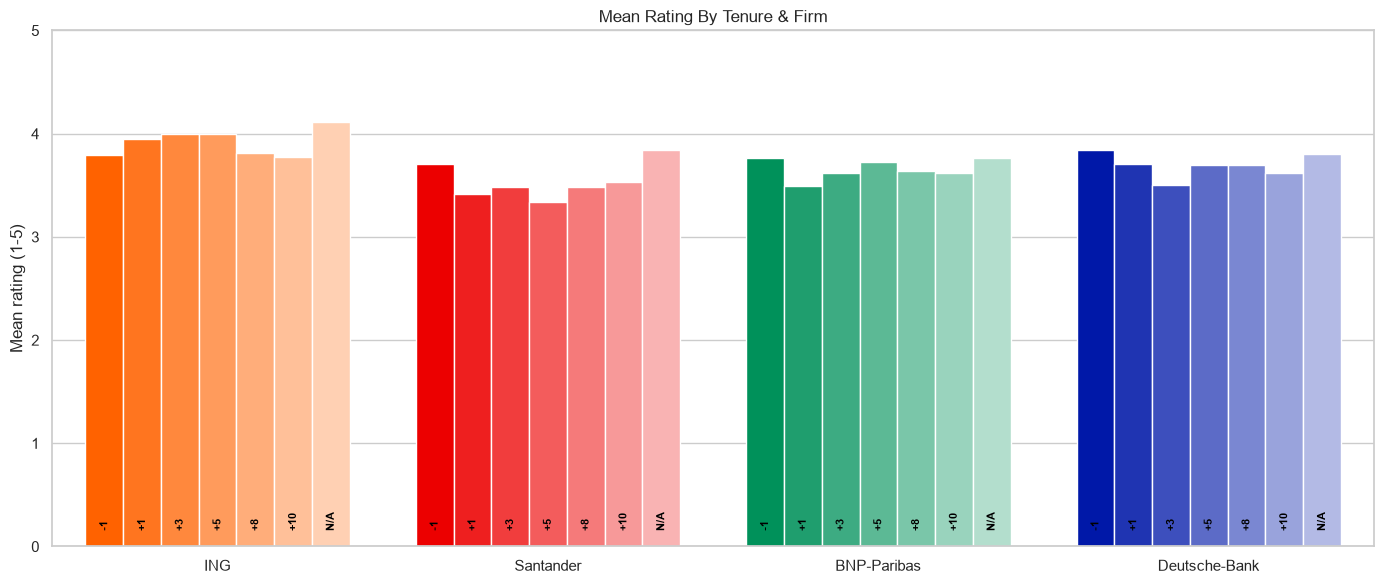

In [54]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=clean_df, 
    x="firm", 
    y="overall_rating", 
    hue="tenure", 
    order=FIRMS,
    errorbar=None, 
    ax=ax
)

# Remove useles legend
if ax.get_legend():
    ax.get_legend().remove()

categories = clean_df['tenure'].cat.categories

for i, container in enumerate(ax.containers):
    amount = i * 0.12  
    tenure_label = categories[i]
    for bar, firm in zip(container, FIRMS):
        base_color = PALETTE.get(firm, "#616161")
        bar.set_facecolor(lighten(base_color, min(amount, 0.7)))
        
        # Metemos el tenure en la base de la barra con texto negro
        x_pos = bar.get_x() + bar.get_width() / 2
        ax.text(
            x_pos, 0.15, tenure_label, 
            ha='center', va='bottom', 
            rotation=90, fontsize=8, 
            color='black', 
            weight='bold'
        )

ax.set_title("Mean Rating By Tenure & Firm")
ax.set_ylabel("Mean rating (1-5)")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

Counter to intuition, tenure curves remain relatively stable across all firms, though each follows a distinct shape: Santander forms a U-shaped valley, with employees in the 3–8 year bracket showing the deepest dissatisfaction. Conversely, ING and BNP display an inverted-U mountain pattern, suggesting employees grow more comfortable over time before eventually burning out at higher tenures. Meanwhile, Deutsche Bank is the epitome of flat stability.

ING's Actionable: Offering more tenure-based benefits can help reduce lower ratings among more experienced workers.

**Whole EDA's Conclusions**
ING starts from a favorable competitive position: it has the highest ratings, a more positive rating distribution, and maintains its advantage among both current and former employees. Moreover, this strength remains consistent throughout the period analyzed and across different levels of tenure. The next step should therefore focus not on demonstrating that ING has a better overall perception, but on identifying the factors that explain this advantage and, particularly, the negative aspects mentioned in reviews from current and former employees that could represent opportunities for improvement.

## 2. Feeling Analysis on Pros/Cons: Quality Check

TEACHER'S EXPLANATION: Los pros y cons  ya nos darían un sentmiento, haremos un control de calidad para verificar que el sentimiento predominante en pros es el positivo y en cons es en negativo. Para ellos puedes emplear alguno de los modelos transaformer ya preentrenados vistos en clase o Vader de nltk que es un modelo de léxico. Ten en cuenta que estos modelos preentrenados algunos califican en neutral. Por ejemplo,  `distilbert-base-uncased-finetuned-sst-2-english`. Es binario (POSITIVE / NEGATIVE, sin clase neutral) y trabaja con un máximo de 512 tokens, por lo que se usa `truncation=True`. Muestra que % de los pros son positivas segun el modelo y quie % de cons son negativas segun en Muestra algún enjemplo de casos discordantes

    #'distilbert-base-uncased-finetuned-sst-2-english', ha tardado 37 min para 47000 reseñas

## 3. Topic Modeling

TEACHER'S EXPLANATION: Podéis usar  BERTopic visto en clase o alguna otra técnica. **IMPORTANTE** **Un único modelo para las 5 empresas** (uno para pros y otro para cons). Si se entrenara un modelo por empresa, los topics no coincidirían y no se podrían comparar. Emplea etiquetas de negopcio para cada topic identificado. Por ejemplo: Compensación y beneficios,  Conciliación, Carrera y desarrollo, management , Cultura, 'Burocracia y procesos, ... Cuantso pros y cons salen por cada topic (%) (& más)

## 4. Peers Comparison

TEACHER'S EXPLANATION: Para cada empresa calculo el % de reseñas cuyos pros caen en cada categoría, y lo mismo con los cons. **Cuidado con la interpretación.** Los porcentajes de cada empresa suman 100%, así que son relativos: si una empresa tiene pocas quejas de salario, el peso de "salario" en sus cons baja, pero sube el del resto aunque nada haya empeorado. Por eso no basta con mirar los cons. Uso el **balance neto**: balance neto = % de reseñas que destacan la categoría en pros − % que la mencionan en cons. Un balance neto por encima del de los peers indica una fortaleza relativa; por debajo, una debilidad relativa.

## 5. Former vs Current Employees

TEACHER'S EXPLANATION: Los cons de quienes ya se han ido son, en la práctica, **motivos de salida**: el input más directo para un plan de retención. Puedes comparar los topic de pros y cons de los empleados actuales vs empleados antiguos. Puedes detectar motivos de abandono en los empleados antiguos. 

## 6. Final Conclusions & Recomendations for HHRR

TEACHER'S EXPLANATION: Iderntifica areas mejora y puntos fuertes de nuestra compañia e identifica palancas para un posible plan de retención y para unb popsible plan de atraccion de nuevo talento.